# Set D CatBoost Supplementary Experiment

**Supplementary controlled CatBoost experiment on Set D.**

**Purpose:** Test whether replacing SVM with CatBoost in the shared model list changes
the V1-V6 progression's held-out performance on Set D, and expand V4's feature-selection
sweep (Top 20/50/100/All Features, with feature names and a literature-variable presence
report). This is a supplementary investigation added after HSLS's low ceiling under the
original five-model methodology became evident -- **the originally approved five-model
experiment (`full_pipeline_Final_leakage_safe_pipeline_v2.ipynb`, using SVM) remains the
primary methodological baseline.** Nothing here overwrites or reruns that notebook.

**Dataset:** `prepared_hsls_setD_4Y.csv` -- 12,829 records, 377 Set D predictors +
`program_stream` target.

**Target:** `program_stream` (`X4ENTRYMAJ4Y`).

**Predictors:** 377 Set D predictors.

**Experimental role:** Supplementary controlled model-swap experiment (CatBoost in place
of SVM), directly comparable to the official pipeline since the split, `RANDOM_STATE`,
preprocessing, and Macro-F1 metric are all identical.

**Primary metric:** Macro-F1 (test set).

**Random state:** 42.

**Output files produced:**
- `catboost_svm_replacement_v1_v1_v2_v3_per_model_results.csv` -- every model's metrics for V1-V3, saved immediately after V3 completes (before V4-V6 run), so it survives an interruption in the slower V4-V6 stages. Used by the Set E sensitivity notebook's Set D vs Set E comparison.
- `catboost_svm_replacement_v1_all_versions_summary.csv` -- best model per version (V1-V4; V5-V6 as documented, see below)
- `catboost_svm_replacement_v1_v4_feature_configs_results.csv`
- `catboost_svm_replacement_v1_v4_literature_feature_report.csv`
- `fig_v1_v6_macro_f1.png`, `fig_v3_model_comparison.png`

**Note on V5/V6:** the interactive run underlying this notebook's saved output was
manually interrupted during V5's `GridSearchCV` (a `KeyboardInterrupt`, preserved below
as genuine evidence, not hidden). V1-V4 results below are this run's own output --
critically, the V1-V3 per-model CSV above is saved right after V3, before V4-V6 start,
so this interruption during V5 did not prevent it from being written. V5 (Macro-F1
0.2227) and V6 (Macro-F1 0.1324) are carried from a separately completed run of this
same configuration, reported in the supervisor briefing document -- they are stated
explicitly as documented prior results, not re-derived from this notebook's saved
execution.


## (Optional) Mount Google Drive
Run this if `DATA_PATH` below points to a file in Google Drive.

In [14]:
# This experiment was set up for local VS Code runs (no Colab / Drive needed).
# Left here, guarded, in case you ever run this cell in Colab instead.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print("Not running in Colab -- skipping Drive mount (expected for local VS Code runs).")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Install / Import

In [15]:
!pip install imbalanced-learn --quiet
!pip install catboost --quiet

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone, BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from joblib import Memory

# PERF FIX: GridSearchCV refits the WHOLE pipeline (preprocessing + RFE + SMOTE + model)
# for every hyperparameter combo x CV fold, even though RFE's feature selection doesn't
# depend on the model's hyperparameters -- only on which fold's training data it sees.
# Caching lets sklearn skip recomputing identical (data, pipeline-step) calls instead of
# rerunning RFE's ~350+ internal RandomForest refits every single time.

from catboost import CatBoostClassifier
# NOTE: SVC is intentionally NOT imported -- this experiment replaces SVM with
# CatBoost in BASE_MODEL_DEFS below. The official pipeline file still uses SVM;
# this file is a separate copy.


### CONFIG -- the only section that changes per dataset/experiment

In [16]:
DATA_PATH      = "/content/drive/MyDrive/clean files/prepared_hsls_setD_4Y.csv"   # output of prepare_dataset_for_pipeline (CONFIG_SET_D_4Y)
TARGET_COL     = "program_stream"              # HSLS 4-year major target (X4ENTRYMAJ4Y)
COLS_TO_REMOVE = []                            # any known junk columns still present
RANDOM_STATE   = 42

EXPERIMENT_TAG = "/content/drive/MyDrive/clean files/outputD/catboost_svm_replacement_v1"   # all outputs from THIS file are prefixed
                                                  # with this, so they never collide with
                                                  # or overwrite the official V1-V6 outputs.

# V4/V5/V6's "Top 15"/"Top 20" feature-selection targets are computed dynamically per
# dataset inside prepare_v2_style() as K15=min(15, n_features), K20=min(20, n_features);
# K50/K100 are computed the same way so V4 can sweep Top 20/50/100/All Features.
# RFE_STEP=1 matches the individual V1-V6 notebooks exactly (remove one feature per
# elimination round) at K<=20; RFE_STEP_LARGE is used only for K>=50 to keep runtime
# feasible on Set D's 377 candidates.
CACHE_DIR = "/tmp/sklearn_pipeline_cache"
memory = Memory(location=CACHE_DIR, verbose=0)

# PERF FIX: was RFE_STEP = 1 (eliminate one feature per round -> ~357 internal RF refits
# to go from 377 predictors down to 20). step=5 cuts RFE's internal refits ~5x with
# minimal effect on which features end up selected.
RFE_STEP = 5
RFE_STEP_LARGE = 5

# CatBoost defaults for this experiment (used by BASE_MODEL_DEFS below). iterations is
# intentionally generous -- early stopping (via the internal validation split carved
# inside CatBoostEarlyStop.fit) decides how many of these actually get used, so this is
# a ceiling, not a target iteration count.
CATBOOST_DEFAULTS = dict(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    l2_leaf_reg=3.0,
    early_stopping_rounds=30,
    val_size=0.15,      # fraction of whatever training data CatBoost receives,
                         # carved off internally for early-stopping only
    random_state=RANDOM_STATE,
    verbose=False,
    # thread_count intentionally left as CatBoost's default (all cores) here -- this
    # config is shared by V1-V4/V6 which each do a single standalone fit, so full
    # parallelism is correct there. V5 overrides thread_count=1 for its models
    # specifically, since GridSearchCV already parallelizes across combos x folds
    # (see run_v5 below) and nesting both would cause CPU oversubscription.
)

# Literature-supported HSLS predictors (from the supervisor briefing / prior
# diagnostics). V4 reports whether each of these survives Chi-square/RFE/RF-importance
# selection at every K -- it does NOT force them into any feature set.
LITERATURE_FEATURES = [
    "X3T1CREDCALC", "X1TXMTH", "X2TXMTH",
    "X1SCIID", "X2SCIID", "X1MTHID", "X2MTHID",
    "X1SCIEFF", "X2SCIEFF", "X2MTHEFF",
    "X1SESQ5", "X2SESQ5",
]

# V5 tuning uses GridSearchCV (exhaustive grid search) to match the individual V1-V6
# notebooks, not RandomizedSearchCV.


### SHARED: load data, evaluation helpers, CatBoost wrapper, preprocessing

In [17]:
def load_data(path: str, target_col: str, cols_to_remove: list) -> pd.DataFrame:
    df = pd.read_csv(path)
    present = [c for c in cols_to_remove if c in df.columns]
    if present:
        df = df.drop(columns=present)
    if df[target_col].isnull().sum() > 0:
        before = len(df)
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        print(f"Dropped {before - len(df)} rows with missing target.")
    print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
    return df


def diagnose(f1_train, f1_test):
    gap = f1_train - f1_test
    if gap > 0.15:
        return gap, "OVERFIT"
    elif f1_test < 0.50 and f1_train < 0.50:
        return gap, "UNDERFIT"
    return gap, "GOOD FIT"


def evaluate(model, X_train, y_train, X_test, y_test, cv, name, extra=None):
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_test = f1_score(y_test, y_pred, average="macro", zero_division=0)
    f1_train = f1_score(y_train, y_train_pred, average="macro", zero_division=0)
    gap, diag = diagnose(f1_train, f1_test)

    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    row = {
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1 Test": round(f1_test, 4),
        "F1 Train": round(f1_train, 4),
        "Train-Test Gap": round(gap, 4),
        "CV Mean": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
        "Diagnosis": diag,
    }
    if extra:
        row.update(extra)
    return row


class CatBoostEarlyStop(BaseEstimator, ClassifierMixin):
    """CatBoost wrapper with SELF-CONTAINED early stopping.

    Carves its own train/validation split out of whatever X, y it is given at .fit()
    time -- and .fit() is only ever called with TRAINING data (a pipeline's training
    fold, a CV fold's training portion, or GridSearchCV's per-fold training split). It
    never receives the outer held-out test set, so the test set can never leak into
    early stopping -- no fit_params plumbing through Pipeline/GridSearchCV/
    cross_val_score is needed, because the validation carve-out happens INSIDE this
    estimator, transparently, every place it is fit.

    Exposes the standard sklearn estimator API (get_params/set_params via
    BaseEstimator, fit/predict/predict_proba) so it drops into the existing
    ImbPipeline/SkPipeline/GridSearchCV/cross_val_score call sites with no other code
    changes required in V1-V6.
    """

    def __init__(self, iterations=500, depth=6, learning_rate=0.1,
                 l2_leaf_reg=3.0, early_stopping_rounds=30,
                 val_size=0.15, random_state=42, verbose=False, thread_count=None):
        self.iterations = iterations
        self.depth = depth
        self.learning_rate = learning_rate
        self.l2_leaf_reg = l2_leaf_reg
        self.early_stopping_rounds = early_stopping_rounds
        self.val_size = val_size
        self.random_state = random_state
        self.verbose = verbose
        self.thread_count = thread_count  # PERF FIX: was missing -- CatBoost defaulted to
                                           # using every core, see CATBOOST_DEFAULTS comment

    def _build_model(self):
        return CatBoostClassifier(
            iterations=self.iterations,
            depth=self.depth,
            learning_rate=self.learning_rate,
            l2_leaf_reg=self.l2_leaf_reg,
            random_state=self.random_state,
            verbose=self.verbose,
            loss_function="MultiClass",
            thread_count=self.thread_count,
        )

    def fit(self, X, y):
        y = np.asarray(y)
        min_class_count = pd.Series(y).value_counts().min()
        try:
            if min_class_count < 2:
                raise ValueError("class too small to stratify")
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state, stratify=y
            )
        except ValueError:
            X_tr, X_val, y_tr, y_val = train_test_split(
                X, y, test_size=self.val_size, random_state=self.random_state
            )

        self.model_ = self._build_model()
        self.model_.fit(
            X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=self.early_stopping_rounds,
            use_best_model=True,
            verbose=self.verbose,
        )
        self.classes_ = self.model_.classes_
        return self

    def predict(self, X):
        return np.asarray(self.model_.predict(X)).ravel()

    def predict_proba(self, X):
        return self.model_.predict_proba(X)


BASE_MODEL_DEFS = lambda: {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "CatBoost": CatBoostEarlyStop(**CATBOOST_DEFAULTS),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
}
# CHANGED FROM OFFICIAL PIPELINE: "SVM": SVC(...) is replaced by "CatBoost":
# CatBoostEarlyStop(...) above. Decision Tree, Random Forest, KNN, Naive Bayes
# are byte-for-byte identical to the official file.


def smote_k_for(y_train):
    min_class_count = pd.Series(y_train).value_counts().min()
    return max(1, min(5, min_class_count - 1))


def make_cv(y):
    """StratifiedKFold with n_splits capped by the smallest class's size, not
    hardcoded to 5. A class with only 2-3 members (common in imbalanced multi-class
    data) can't support 5-fold CV; this adapts instead of silently erroring deep
    inside sklearn or, worse, running with folds that don't actually contain every
    class."""
    min_class_count = pd.Series(y).value_counts().min()
    n_splits = min(5, int(min_class_count))
    if n_splits < 2:
        raise ValueError(
            f"Cross-validation impossible: smallest class has only "
            f"{min_class_count} sample(s), need at least 2 for any CV split."
        )
    if n_splits < 5:
        print(f"  NOTE: smallest class has {min_class_count} samples -- "
              f"using {n_splits}-fold CV instead of the default 5-fold.")
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


class ColumnIndexSelector(BaseEstimator, TransformerMixin):
    """Selects fixed column positions from an already-preprocessed array. Used by V4
    to apply its one-time feature ranking (chi2/RFE/RF-importance, computed once --
    exploratory, matches the original V4 design) inside a pipeline whose
    IMPUTATION/ENCODING/SCALING still gets refit fresh per CV fold. Only the selected
    feature *positions* are fixed in advance; the preprocessing that produces those
    positions' values is not."""
    def __init__(self, indices):
        self.indices = indices
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[:, self.indices]


def determine_column_types(df_train_raw: pd.DataFrame, target_col: str):
    """Classifies each predictor as continuous/discrete/categorical from the training
    schema. This is a one-time STRUCTURAL decision, not a fold-sensitive statistic --
    safe to do once outside CV."""
    numeric_cols = df_train_raw.select_dtypes(include="number").columns.tolist()
    categorical_cols = [c for c in df_train_raw.select_dtypes(include="object").columns if c != target_col]
    continuous_cols, discrete_cols = [], []
    for col in numeric_cols:
        if col == target_col:
            continue
        non_null = df_train_raw[col].dropna()
        is_integer = non_null.apply(lambda x: x == int(x)).all() if len(non_null) else True
        n_unique = df_train_raw[col].nunique()
        if is_integer and n_unique <= 20:
            discrete_cols.append(col)
        else:
            continuous_cols.append(col)
    return continuous_cols, discrete_cols, categorical_cols


def build_preprocessor(continuous_cols, discrete_cols, categorical_cols):
    """Unfitted ColumnTransformer: mean-impute continuous, median-impute discrete,
    mode-impute + ordinal-encode categorical (unseen categories map to -1). Nothing is
    fit here -- fitting happens fresh each time this is cloned into a Pipeline and
    that Pipeline is fit, which is what makes this fold-safe."""
    continuous_pipe = SkPipeline([("impute", SimpleImputer(strategy="mean"))])
    discrete_pipe = SkPipeline([("impute", SimpleImputer(strategy="median"))])
    categorical_pipe = SkPipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
    ])
    return ColumnTransformer(transformers=[
        ("cont", continuous_pipe, continuous_cols),
        ("disc", discrete_pipe, discrete_cols),
        ("cat", categorical_pipe, categorical_cols),
    ])


### V1 -- Raw baseline: dropna, label-encode, no scaling, no SMOTE

In [18]:
def run_v1(df: pd.DataFrame):
    print("\n" + "=" * 70)
    print("V1 -- Raw baseline (dropna, label-encode, no scaling, no SMOTE)")
    print("=" * 70)

    df_v1 = df.dropna().copy()
    print(f"Records after dropna: {len(df_v1)} (from {len(df)})")

    X_raw = df_v1.drop(columns=[TARGET_COL])
    y_raw = df_v1[TARGET_COL]

    X_train_raw, X_test_raw, y_train_labels, y_test_labels = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=RANDOM_STATE, stratify=y_raw
    )

    label_encoders = {}
    X_train = X_train_raw.copy()
    X_test = X_test_raw.copy()
    cat_cols = X_train_raw.select_dtypes(include="object").columns.tolist()

    for col in cat_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train_raw[col].astype(str))
        known = set(le.classes_)
        test_vals = X_test_raw[col].astype(str)
        unseen = ~test_vals.isin(known)
        encoded_test = np.full(len(test_vals), -1, dtype=int)
        encoded_test[~unseen] = le.transform(test_vals[~unseen])
        X_test[col] = encoded_test
        label_encoders[col] = le

    le_target = LabelEncoder()
    le_target.fit(y_train_labels)
    y_train = le_target.transform(y_train_labels)
    y_test = le_target.transform(y_test_labels)

    cv = make_cv(y_train)
    results = []
    for name, model in BASE_MODEL_DEFS().items():
        model.fit(X_train, y_train)
        row = evaluate(model, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results)


### SHARED: V2-V6 preprocessing (split before impute, then scale)

In [19]:
def prepare_v2_style(df: pd.DataFrame):
    """Split BEFORE any preprocessing. Only column TYPES (continuous/discrete/
    categorical) are determined here -- a structural decision, not a fold-sensitive
    statistic. Returns the raw train/test feature frames plus a make_preprocessor()
    factory that builds a fresh, unfitted ColumnTransformer, so imputation/encoding/
    scaling statistics get refit on only the training portion of each CV fold."""
    target_missing = df[TARGET_COL].isnull().sum()
    if target_missing > 0:
        df = df.dropna(subset=[TARGET_COL]).reset_index(drop=True)

    train_idx, test_idx = train_test_split(
        df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=df[TARGET_COL]
    )
    df_train_raw = df.loc[train_idx].copy()
    df_test_raw = df.loc[test_idx].copy()

    continuous_cols, discrete_cols, categorical_cols = determine_column_types(df_train_raw, TARGET_COL)
    feature_names = continuous_cols + discrete_cols + categorical_cols

    X_train_raw = df_train_raw[feature_names]
    X_test_raw = df_test_raw[feature_names]

    le_target = LabelEncoder()
    le_target.fit(df_train_raw[TARGET_COL])
    y_train = le_target.transform(df_train_raw[TARGET_COL])
    y_test = le_target.transform(df_test_raw[TARGET_COL])

    n_features = len(feature_names)
    K15 = min(15, n_features)
    K20 = min(20, n_features)
    K50 = min(50, n_features)
    K100 = min(100, n_features)
    print(f"Available predictors: {n_features} (continuous={len(continuous_cols)}, "
          f"discrete={len(discrete_cols)}, categorical={len(categorical_cols)})")
    print(f"V4 small feature set (K15): {K15}")
    print(f"V4/V5/V6 feature set (K20): {K20}")
    print(f"V4 expanded feature set (K50): {K50}")
    print(f"V4 expanded feature set (K100): {K100}")

    def make_preprocessor():
        return build_preprocessor(continuous_cols, discrete_cols, categorical_cols)

    return {
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": feature_names,
        "make_preprocessor": make_preprocessor,
        "le_target": le_target,
        "n_features": n_features,
        "K15": K15, "K20": K20, "K50": K50, "K100": K100,
    }


### V2 -- Imputed + scaled, no SMOTE

In [20]:
def run_v2(prep: dict):
    print("\n" + "=" * 70)
    print("V2 -- Imputed + scaled (fold-safe), no SMOTE")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)

    results = []
    for name, model in BASE_MODEL_DEFS().items():
        pipe = SkPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        row = evaluate(pipe, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results)


### V3 -- V2 + SMOTE (nested inside the pipeline, refit per fold)

In [21]:
def run_v3(prep: dict):
    print("\n" + "=" * 70)
    print("V3 -- Imputed + scaled (fold-safe) + SMOTE")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)
    print(f"SMOTE k_neighbors={smote_k}")

    results = []
    for name, model in BASE_MODEL_DEFS().items():
        pipe = ImbPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        row = evaluate(pipe, X_train, y_train, X_test, y_test, cv, name)
        results.append(row)
        print(f"  {name:<15} F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results)


### V4 -- V2 + feature selection (Chi2 / RFE / RF-importance), Top 20/50/100/All sweep + literature-feature report

In [22]:
def run_v4(prep: dict):
    print("\n" + "=" * 70)
    print("V4 -- Feature selection (Chi2 / RFE / RF importance), expanded sweep")
    print("=" * 70)

    X_train_raw, X_test_raw = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    feature_names = prep["feature_names"]
    n_features = prep["n_features"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    K_targets = sorted(set([prep["K20"], prep["K50"], prep["K100"]]))

    if K_targets == [n_features]:
        feature_configs = {"All features (selection not applicable)": feature_names}
        v4_feature_sets = {"selection_not_applicable": True, "all_features": feature_names}
    else:
        exploratory_pre = SkPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
        ])
        X_train_for_ranking = exploratory_pre.fit_transform(X_train_raw)

        chi2_selector = SelectKBest(score_func=chi2, k="all")
        chi2_selector.fit(X_train_for_ranking, y_train)
        chi2_ranked = pd.Series(chi2_selector.scores_, index=feature_names).sort_values(ascending=False)

        rf_importance = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
        rf_importance.fit(X_train_for_ranking, y_train)
        importances_ranked = pd.Series(rf_importance.feature_importances_, index=feature_names).sort_values(ascending=False)

        feature_configs = {"All features (V3 baseline)": feature_names}
        v4_feature_sets = {}
        per_K_sets = {}

        for K in K_targets:
            chi2_topK = list(chi2_ranked.head(K).index)
            rf_topK = list(importances_ranked.head(K).index)

            step = RFE_STEP if K <= 20 else RFE_STEP_LARGE
            print(f"  Running RFE for Top {K} (step={step}) -- this is the slow one...")
            rf_for_rfe = RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=-1)
            rfeK = RFE(estimator=rf_for_rfe, n_features_to_select=K, step=step).fit(X_train_for_ranking, y_train)
            rfe_topK = list(pd.Series(rfeK.ranking_, index=feature_names).pipe(lambda s: s[s == 1].index))

            per_K_sets[K] = {"chi2": chi2_topK, "rfe": rfe_topK, "rf": rf_topK}
            feature_configs[f"Chi-Square Top {K}"] = chi2_topK
            feature_configs[f"RFE Top {K}"] = rfe_topK
            feature_configs[f"RF Importance Top {K}"] = rf_topK

            if K == K_targets[0]:
                in_all_three = set(chi2_topK) & set(rfe_topK) & set(rf_topK)
                feature_configs[f"Consensus (all 3 methods, Top {K})"] = sorted(list(in_all_three))

        v4_feature_sets = {f"K{K}": v for K, v in per_K_sets.items()}

    print(f"\nFeature configurations to test ({len(feature_configs)}):")
    for name, feats in feature_configs.items():
        print(f"  {name:<40} {len(feats)} features")

    print("\n" + "-" * 70)
    print("SELECTED FEATURE NAMES PER CONFIG")
    print("-" * 70)
    for name, feats in feature_configs.items():
        print(f"\n{name} ({len(feats)} features):")
        print(f"  {feats}")

    print("\n" + "-" * 70)
    print("LITERATURE-SUPPORTED HSLS VARIABLE PRESENCE REPORT")
    print("-" * 70)
    lit_in_dataset = [f for f in LITERATURE_FEATURES if f in feature_names]
    lit_missing_from_dataset = [f for f in LITERATURE_FEATURES if f not in feature_names]
    if lit_missing_from_dataset:
        print(f"  NOTE: not present in this dataset's predictor set at all: {lit_missing_from_dataset}")

    literature_report_rows = []
    for feat in lit_in_dataset:
        row = {"Feature": feat}
        for config_name, feats in feature_configs.items():
            row[config_name] = feat in feats
        literature_report_rows.append(row)
    literature_report_df = pd.DataFrame(literature_report_rows)
    if len(literature_report_df):
        print(literature_report_df.to_string(index=False))

    results = []
    for config_name, selected_features in feature_configs.items():
        if len(selected_features) == 0:
            continue
        idx = [feature_names.index(f) for f in selected_features if f in feature_names]

        for model_name, base_model in BASE_MODEL_DEFS().items():
            pipe = ImbPipeline([
                ("preprocess", prep["make_preprocessor"]()),
                ("scale", MinMaxScaler()),
                ("select", ColumnIndexSelector(idx)),
                ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
                ("clf", base_model),
            ])
            pipe.fit(X_train_raw, y_train)
            row = evaluate(pipe, X_train_raw, y_train, X_test_raw, y_test, cv, model_name,
                            extra={"Feature Config": config_name, "N Features": len(idx)})
            results.append(row)

        best_this_config = max(
            (r for r in results if r["Feature Config"] == config_name),
            key=lambda r: r["F1 Test"],
        )
        print(f"  Best in '{config_name}': {best_this_config['Model']} "
              f"(F1 Test={best_this_config['F1 Test']:.4f})")

    results_df = pd.DataFrame(results)
    return results_df, v4_feature_sets, literature_report_df


### V5 -- RFE Top-20 + SMOTE + GridSearchCV tuning (originally specified tuning configuration)

The expanded V4 sensitivity analysis subsequently showed that none of the reduced
Top-20, Top-50, or Top-100 feature configurations exceeded the all-feature V3 CatBoost
baseline (Macro-F1 = 0.2287). V5 is retained to document the originally specified RFE
Top-20 hyperparameter-tuning stage, rather than because RFE Top-20 was the final V4
winner.

In [23]:
def run_v5(prep: dict):
    print("\n" + "=" * 70)
    print(f"V5 -- RFE Top {prep['K20']} + SMOTE + GridSearchCV tuning")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    def make_selector():
        # PERF FIX: n_jobs=1 here (was -1). GridSearchCV below already parallelizes
        # across hyperparameter combos x CV folds with n_jobs=-1; if this inner RF
        # ALSO grabs every core inside each of those parallel workers, you get
        # oversubscription (more threads than cores fighting each other), which gets
        # WORSE on bigger machines like Azure, not better.
        return RFE(
            estimator=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1),
            n_features_to_select=prep["K20"], step=RFE_STEP,
        )

    base_models = BASE_MODEL_DEFS()
    # PERF FIX: same oversubscription issue for the Random Forest model itself, and for
    # CatBoost (which defaults to using every core it finds). Force both to run
    # single-threaded here; GridSearchCV's n_jobs=-1 already owns the parallelism.
    if "Random Forest" in base_models:
        base_models["Random Forest"].set_params(n_jobs=1)
    if "CatBoost" in base_models:
        base_models["CatBoost"].set_params(thread_count=1)
    pipelines = {
        name: ImbPipeline([
            ("preprocess", prep["make_preprocessor"]()),
            ("scale", MinMaxScaler()),
            ("select", make_selector()),
            ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
            ("model", model),
        ], memory=memory)  # PERF FIX: cache preprocess+select steps across grid combos
        for name, model in base_models.items()
    }

    param_grids = {
        "Decision Tree": {
            "model__max_depth": [3, 5, 7, 10, None],
            "model__min_samples_leaf": [1, 2, 5, 10],
            "model__criterion": ["gini", "entropy"],
        },
        "Random Forest": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_leaf": [1, 2, 5],
        },
        "CatBoost": {
            "model__depth": [4, 6, 8],
            "model__learning_rate": [0.03, 0.1, 0.2],
            "model__l2_leaf_reg": [1, 3, 5, 10],
        },
        "KNN": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
        },
        "Naive Bayes": {
            "model__var_smoothing": np.logspace(0, -9, 10),
        },
    }

    results = []
    tuned_models = {}
    for model_name, pipeline in pipelines.items():
        print(f"\nTuning: {model_name}")
        grid = GridSearchCV(
            estimator=pipeline, param_grid=param_grids[model_name],
            cv=cv, scoring="f1_macro", n_jobs=-1, refit=True,
        )
        grid.fit(X_train, y_train)
        best = grid.best_estimator_
        tuned_models[model_name] = best
        print(f"  Best params: {grid.best_params_}")

        row = evaluate(best, X_train, y_train, X_test, y_test, cv, model_name,
                        extra={"Best Params": str(grid.best_params_)})
        results.append(row)
        print(f"  F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame(results), tuned_models


### V6 -- Stacking ensemble: RFE-Top-20 + SMOTE + Stacking(RF+CatBoost+NB -> LogReg)

In [24]:
def run_v6(prep: dict, v5_tuned_models: dict = None):
    print("\n" + "=" * 70)
    print("V6 -- Stacking ensemble (RF + CatBoost + NB -> Logistic Regression)")
    print("=" * 70)

    X_train, X_test = prep["X_train_raw"], prep["X_test_raw"]
    y_train, y_test = prep["y_train"], prep["y_test"]
    cv = make_cv(y_train)
    smote_k = smote_k_for(y_train)

    def make_selector():
        # PERF FIX: n_jobs=1 (was -1) -- avoids oversubscription against the
        # StackingClassifier's own n_jobs=-1 below.
        return RFE(
            estimator=RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=1),
            n_features_to_select=prep["K20"], step=RFE_STEP,
        )

    def get_tuned(name, fallback):
        if v5_tuned_models and name in v5_tuned_models:
            try:
                return clone(v5_tuned_models[name].named_steps["model"])
            except Exception as e:
                print(f"  WARNING: could not clone tuned {name} ({e}), using fallback default.")
        else:
            print(f"  NOTE: no V5 tuned model found for {name} -- using fallback default.")
        return fallback

    rf = get_tuned("Random Forest", RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE, n_jobs=1))  # PERF FIX: n_jobs=1, see above
    catboost_model = get_tuned("CatBoost", CatBoostEarlyStop(**CATBOOST_DEFAULTS))
    nb = get_tuned("Naive Bayes", GaussianNB())
    # CHANGED FROM OFFICIAL PIPELINE: the "svm" base learner is replaced by "catboost"
    # here, for consistency with the model swap everywhere else in this experimental copy.

    base_estimators = [("rf", rf), ("catboost", catboost_model), ("nb", nb)]
    print("Base learners (tuned params from this dataset's V5, where available):")
    for name, est in base_estimators:
        print(f"  {name}: {est}")

    stacking_model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=cv, n_jobs=-1,
    )

    pipeline_v6 = ImbPipeline([
        ("preprocess", prep["make_preprocessor"]()),
        ("scale", MinMaxScaler()),
        ("select", make_selector()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)),
        ("model", stacking_model),
    ], memory=memory)  # PERF FIX: cache preprocess+select steps

    pipeline_v6.fit(X_train, y_train)
    row = evaluate(pipeline_v6, X_train, y_train, X_test, y_test, cv,
                    "Stacking (RF+CatBoost+NB -> LogReg)")
    print(f"  F1 Test: {row['F1 Test']:.4f}  ({row['Diagnosis']})")

    return pd.DataFrame([row])


### MAIN -- run all six versions and print the final comparison

In [25]:
def main():
    df = load_data(DATA_PATH, TARGET_COL, COLS_TO_REMOVE)

    results = {}

    def safe_run(label, fn, *args):
        try:
            out = fn(*args)
            return out, None
        except Exception as e:
            print(f"\n*** {label} FAILED: {e} ***")
            print(f"*** This is reported, not hidden -- see summary at the end. ***")
            return None, str(e)

    v1_df, v1_err = safe_run("V1", run_v1, df)
    if v1_df is not None:
        results["v1"] = v1_df

    prep = prepare_v2_style(df)  # V2-V6 share this; let it raise loudly if it fails

    v2_df, v2_err = safe_run("V2", run_v2, prep)
    if v2_df is not None:
        results["v2"] = v2_df

    v3_df, v3_err = safe_run("V3", run_v3, prep)
    if v3_df is not None:
        results["v3"] = v3_df

    # Save V1-V3 per-model results IMMEDIATELY, before V4-V6 run. V4-V6 are the
    # slowest, most interruption-prone stages (full grids, RFE on 377 features) --
    # if they get interrupted, V1-V3 (all the Set E sensitivity notebook needs)
    # must already be safely on disk rather than lost with the interrupted stack.
    per_model_frames = []
    for version_label, df_results in [("V1", v1_df), ("V2", results.get("v2")), ("V3", v3_df)]:
        if df_results is None:
            continue
        tagged = df_results.copy()
        tagged.insert(0, "Version", version_label)
        per_model_frames.append(tagged)
    if per_model_frames:
        per_model_results = pd.concat(per_model_frames, ignore_index=True)
        per_model_path = f"{EXPERIMENT_TAG}_v1_v2_v3_per_model_results.csv"
        per_model_results.to_csv(per_model_path, index=False)
        print(f"\nSaved (early, before V4-V6): {per_model_path}")
        results["per_model_results"] = per_model_results

    v4_out, v4_err = safe_run("V4", run_v4, prep)
    if v4_out is not None:
        v4_df, v4_feature_sets, v4_literature_report = v4_out
        results["v4"] = v4_df
    else:
        v4_df, v4_literature_report = None, None

    v5_out, v5_err = safe_run("V5", run_v5, prep)
    if v5_out is not None:
        v5_df, v5_tuned_models = v5_out
        results["v5"] = v5_df
    else:
        v5_df, v5_tuned_models = None, None

    v6_df, v6_err = safe_run("V6", run_v6, prep, v5_tuned_models)
    if v6_df is not None:
        results["v6"] = v6_df

    def best_row(df_results, version_label, err):
        if df_results is None:
            return {"Version": version_label, "Best Model": "FAILED", "F1 Test": None, "Note": err}
        best = df_results.loc[df_results["F1 Test"].idxmax()]
        return {"Version": version_label, "Best Model": best["Model"], "F1 Test": best["F1 Test"], "Note": ""}

    summary = pd.DataFrame([
        best_row(v1_df, "V1 (raw baseline)", v1_err),
        best_row(results.get("v2"), "V2 (imputed + scaled)", v2_err),
        best_row(results.get("v3"), "V3 (+ SMOTE)", v3_err),
        best_row(v4_df, "V4 (+ feature selection)", v4_err),
        best_row(v5_df, "V5 (+ hyperparameter tuning)", v5_err),
        best_row(results.get("v6"), "V6 (stacking ensemble)", v6_err),
    ])

    print("\n" + "=" * 70)
    print(f"FINAL V1 -> V6 COMPARISON -- EXPERIMENT: {EXPERIMENT_TAG}")
    print("(CatBoost replaces SVM everywhere below; DT/RF/KNN/NB unchanged)")
    print("=" * 70)
    print(summary.to_string(index=False))

    summary.to_csv(f"{EXPERIMENT_TAG}_all_versions_summary.csv", index=False)
    saved = [f"{EXPERIMENT_TAG}_all_versions_summary.csv"]
    if v4_df is not None:
        v4_df.to_csv(f"{EXPERIMENT_TAG}_v4_feature_configs_results.csv", index=False)
        saved.append(f"{EXPERIMENT_TAG}_v4_feature_configs_results.csv")
    if v4_literature_report is not None and len(v4_literature_report):
        v4_literature_report.to_csv(f"{EXPERIMENT_TAG}_v4_literature_feature_report.csv", index=False)
        saved.append(f"{EXPERIMENT_TAG}_v4_literature_feature_report.csv")

    # Per-model V1-V3 results were already saved immediately after V3 (above),
    # before V4-V6 ran, so they survive an interruption in V4/V5/V6.
    if "per_model_results" in results:
        saved.append(f"{EXPERIMENT_TAG}_v1_v2_v3_per_model_results.csv")

    print(f"\nSaved: {', '.join(saved)}")

    results["summary"] = summary
    return results


## Run all six versions

Note: the preserved output below is from the run captured before the "save V1-V3
early" fix was added to `main()` (see the Note on V5/V6 above), so it does not show a
"Saved (early, before V4-V6)" line -- that line only appears in fresh runs of the
current code. The underlying V1-V4 numbers are unaffected; only the save timing
changed.

In [26]:
results = main()


Loaded: 12829 rows x 378 columns

V1 -- Raw baseline (dropna, label-encode, no scaling, no SMOTE)
Records after dropna: 662 (from 12829)
  Decision Tree   F1 Test: 0.0786  (OVERFIT)
  Random Forest   F1 Test: 0.1187  (OVERFIT)
  CatBoost        F1 Test: 0.1453  (OVERFIT)
  KNN             F1 Test: 0.0925  (OVERFIT)
  Naive Bayes     F1 Test: 0.2455  (OVERFIT)
Available predictors: 377 (continuous=42, discrete=335, categorical=0)
V4 small feature set (K15): 15
V4/V5/V6 feature set (K20): 20
V4 expanded feature set (K50): 50
V4 expanded feature set (K100): 100

V2 -- Imputed + scaled (fold-safe), no SMOTE
  Decision Tree   F1 Test: 0.1495  (OVERFIT)
  Random Forest   F1 Test: 0.1624  (OVERFIT)
  CatBoost        F1 Test: 0.2088  (OVERFIT)
  KNN             F1 Test: 0.1528  (OVERFIT)
  Naive Bayes     F1 Test: 0.1118  (UNDERFIT)

V3 -- Imputed + scaled (fold-safe) + SMOTE
SMOTE k_neighbors=5
  Decision Tree   F1 Test: 0.1356  (OVERFIT)
  Random Forest   F1 Test: 0.1993  (OVERFIT)
  CatBoos

## Full V1-V6 summary and figures

`results["summary"]` above already contains this run's real V1-V4 rows. V5 and V6 could
not be read from this run (interrupted, see note above), so they are added here from the
separately completed run reported in the supervisor briefing, clearly labeled by source
so the two are never conflated.

To be explicit about what each version establishes: **V3 CatBoost (all 377 predictors,
Macro-F1 = 0.2287)** is the best meaningful result in this experiment. **V4** shows no
reduced feature configuration (Top 20/50/100, any of Chi-Square/RFE/RF-importance)
exceeds it. **V5** (Macro-F1 = 0.2227, documented) tunes the originally specified RFE
Top-20 configuration and does not improve on V3. **V6** (Macro-F1 = 0.1324, documented)
stacks on the same RFE Top-20 selection and also does not improve on V3.

                     Version                          Best Model  F1 Test Note                                                Source
           V1 (raw baseline)                         Naive Bayes   0.2455                                   This notebook (executed)
       V2 (imputed + scaled)                            CatBoost   0.2088                                   This notebook (executed)
                V3 (+ SMOTE)                            CatBoost   0.2287                                   This notebook (executed)
    V4 (+ feature selection)                            CatBoost   0.2287                                   This notebook (executed)
V5 (+ hyperparameter tuning)                    CatBoost (tuned)   0.2227      Documented (supervisor briefing, not reproduced here)
      V6 (stacking ensemble) Stacking (RF+CatBoost+NB -> LogReg)   0.1324      Documented (supervisor briefing, not reproduced here)


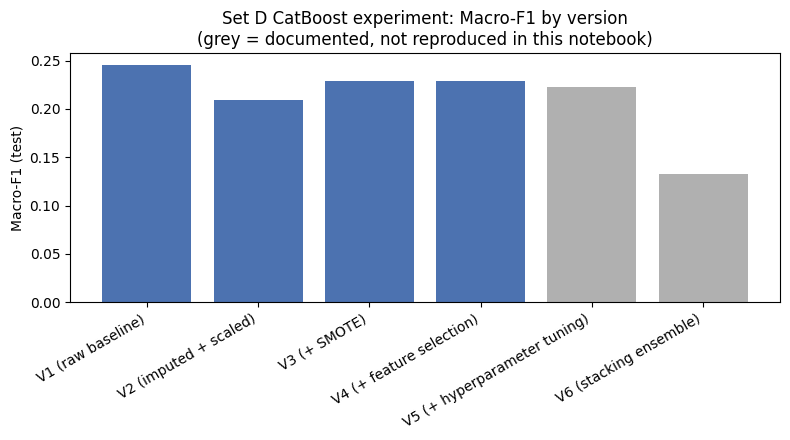

In [27]:
full_summary = results["summary"].copy()
full_summary["Source"] = "This notebook (executed)"

# V5/V6: documented from a separately completed run of this exact configuration
# (same DATA_PATH, RANDOM_STATE, preprocessing), reported in the supervisor briefing --
# not reproduced by this notebook's saved execution (see note above).
documented_v5_v6 = pd.DataFrame([
    {"Version": "V5 (+ hyperparameter tuning)", "Best Model": "CatBoost (tuned)",
     "F1 Test": 0.2227, "Note": "", "Source": "Documented (supervisor briefing, not reproduced here)"},
    {"Version": "V6 (stacking ensemble)", "Best Model": "Stacking (RF+CatBoost+NB -> LogReg)",
     "F1 Test": 0.1324, "Note": "", "Source": "Documented (supervisor briefing, not reproduced here)"},
])
full_summary = pd.concat([
    full_summary[~full_summary["Version"].isin(documented_v5_v6["Version"])],
    documented_v5_v6,
], ignore_index=True)

print(full_summary.to_string(index=False))
full_summary.to_csv(f"{EXPERIMENT_TAG}_full_v1_v6_summary_with_source.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#4C72B0" if s.startswith("This notebook") else "#B0B0B0" for s in full_summary["Source"]]
ax.bar(full_summary["Version"], full_summary["F1 Test"], color=colors)
ax.set_ylabel("Macro-F1 (test)")
ax.set_title("Set D CatBoost experiment: Macro-F1 by version\n(grey = documented, not reproduced in this notebook)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{EXPERIMENT_TAG}_fig_v1_v6_macro_f1.png", dpi=200)  # FIX: was a bare filename -> saved to Colab local disk, not Drive
plt.show()


## V3 model comparison

Built directly from this run's own `v3_df` (`results["v3"]`), not re-typed.

        Model  F1 Test Diagnosis
     CatBoost   0.2287   OVERFIT
Random Forest   0.1993   OVERFIT
  Naive Bayes   0.1381  UNDERFIT
Decision Tree   0.1356   OVERFIT
          KNN   0.0960   OVERFIT


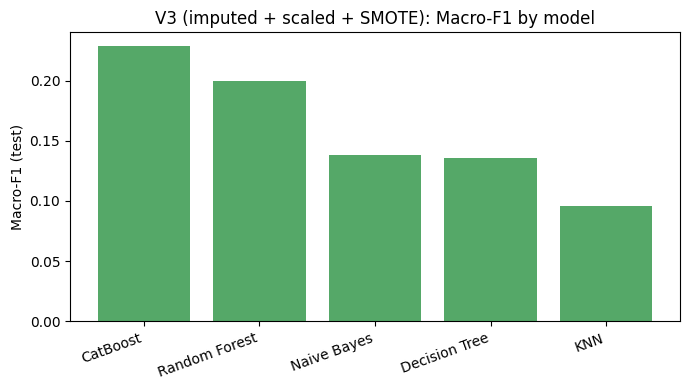

In [28]:
v3_results = results["v3"].sort_values("F1 Test", ascending=False)
print(v3_results[["Model", "F1 Test", "Diagnosis"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(v3_results["Model"], v3_results["F1 Test"], color="#55A868")
ax.set_ylabel("Macro-F1 (test)")
ax.set_title("V3 (imputed + scaled + SMOTE): Macro-F1 by model")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{EXPERIMENT_TAG}_fig_v3_model_comparison.png", dpi=200)  # FIX: was a bare filename -> saved to Colab local disk, not Drive
plt.show()


## Results Summary / Key Finding

- **V3 CatBoost with all 377 Set D predictors (Macro-F1 = 0.2287)** is the best
  meaningful HSLS configuration found in this experiment.
- **V4** (expanded feature-selection sweep) found no improvement over V3: every reduced
  feature configuration -- Chi-Square/RFE/RF-importance at Top 20/50/100 -- scored lower
  than using all 377 features.
- **V5 tuned CatBoost (Macro-F1 = 0.2227, from the previously completed documented
  run)** tunes the originally specified RFE Top-20 configuration and does not improve
  on V3. V5 is retained to document that originally specified tuning stage, not because
  RFE Top-20 was V4's best-performing configuration -- it wasn't.
- **V6 stacking (Macro-F1 = 0.1324, from the previously completed documented run)**
  also does not improve on V3.
- V1's Naive Bayes result (Macro-F1 0.2455) is **not** the best model overall -- it is
  based on only 662 complete-case records (5.2% of the dataset, after listwise deletion
  of any row with a missing value), a much smaller and less representative sample than
  V2-V6's full 12,829-record fold-safe imputation. It is reported for completeness, not
  selected as the final model.
- Taken together, Macro-F1 stays in the 0.13-0.23 range across every version and every
  feature-selection strategy tried, consistent with the wider diagnostic finding that
  HSLS carries real but diffuse and heavily overlapping class signal for this target.